In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/netflix-dataset/netflix_titles.csv


In [2]:
import os

# Dekhein dataset kahan available hai
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/muhammadumer7804/netflix-dataset/netflix_titles.csv


In [3]:
import pandas as pd
import numpy as np
# Load Dataset
df = pd.read_csv('/kaggle/input/datasets/muhammadumer7804/netflix-dataset/netflix_titles.csv')
print("Dataset Load Successfully")
print("Shape", df.shape)

Dataset Load Successfully
Shape (8807, 12)


In [4]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [7]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [10]:
# remove these value or fix
df[df['rating'].isin(['74 min','84 min', '66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [11]:
# Step 1: duration column mein rating ki value copy karna (jahan duration NaN hai aur rating mein "min" hai)
mask = df['rating'].isin(['74 min', '84 min', '66 min'])

df.loc[mask, 'duration'] = df.loc[mask, 'rating']

# Step 2: rating column mein yeh galat values ko NaN se replace karna
df.loc[mask, 'rating'] = np.nan

# Verify karein ke fix ho gaya
print(df.loc[mask, ['title', 'rating', 'duration']])

                                     title rating duration
5541                       Louis C.K. 2017    NaN   74 min
5794                 Louis C.K.: Hilarious    NaN   84 min
5813  Louis C.K.: Live at the Comedy Store    NaN   66 min


In [12]:
print("Rating missing values:", df['rating'].isnull().sum())

# Dekhte hain konsi rows hain
df[df['rating'].isnull()]

Rating missing values: 7


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [13]:
# Missing rating ko 'Not Rated' se fill karna
df['rating'] = df['rating'].fillna('Not Rated')

# Verify karein
print("Missing values remaining:", df['rating'].isnull().sum())
print(df['rating'].value_counts())

Missing values remaining: 0
rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
Not Rated       7
TV-Y7-FV        6
NC-17           3
UR              3
Name: count, dtype: int64


In [14]:
print("Duration missing values:", df['duration'].isnull().sum())

# Agar koi bachi hai to dekhein
df[df['duration'].isnull()]

Duration missing values: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [15]:
print("date_added missing values:", df['date_added'].isnull().sum())

df[df['date_added'].isnull()]

date_added missing values: 10


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [16]:
# Rows drop karna jahan date_added missing hai
df = df.dropna(subset=['date_added'])

# Verify karein
print("New shape:", df.shape)
print("date_added missing values:", df['date_added'].isnull().sum())

New shape: (8797, 12)
date_added missing values: 0


In [17]:
# Check karein abhi format kaisa hai
print(df['date_added'].head())
print(df['date_added'].dtype)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object
object


In [18]:
# date_added ko datetime mein convert karna
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Verify karein
print(df['date_added'].dtype)
print(df['date_added'].head())

datetime64[ns]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [19]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Verify karein
print(df[['date_added', 'year_added', 'month_added']].head())

  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


In [20]:
print(df['country'].value_counts().head(10))
print("\nMissing values:", df['country'].isnull().sum())

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Missing values: 830


In [21]:
df['country'] = df['country'].fillna('Unknown')

# Verify karein
print("Missing values:", df['country'].isnull().sum())
print(df['country'].value_counts().head(10))

Missing values: 0
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [22]:
print("Missing values:", df['cast'].isnull().sum())
print(df['cast'].head(10))

Missing values: 825
0                                                  NaN
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                                  NaN
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
5    Kate Siegel, Zach Gilford, Hamish Linklater, H...
6    Vanessa Hudgens, Kimiko Glenn, James Marsden, ...
7    Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...
8    Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...
9    Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...
Name: cast, dtype: object


In [23]:
df['cast'] = df['cast'].fillna('Unknown')

# Verify karein
print("Missing values:", df['cast'].isnull().sum())

Missing values: 0


In [24]:
print("Missing values:", df['director'].isnull().sum())
print("\nMissing % of director by type:")
print(df[df['director'].isnull()]['type'].value_counts())

Missing values: 2624

Missing % of director by type:
type
TV Show    2436
Movie       188
Name: count, dtype: int64


In [25]:
df['director'] = df['director'].fillna('Unknown')

# Verify karein - poora dataset check
print("Missing values:\n", df.isnull().sum())

Missing values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64


In [26]:
print(df['duration'].head(10))
print(df[df['type']=='Movie']['duration'].head(5))
print(df[df['type']=='TV Show']['duration'].head(5))

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
6       91 min
7      125 min
8    9 Seasons
9      104 min
Name: duration, dtype: object
0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
Name: duration, dtype: object
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
Name: duration, dtype: object


In [27]:
# Movies ke liye: minutes nikalna (numeric)
df['duration_minutes'] = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float)

# TV Shows ke liye: seasons nikalna (numeric)
df['duration_seasons'] = df[df['type'] == 'TV Show']['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float)

# Verify karein
print(df[df['type']=='Movie'][['duration', 'duration_minutes']].head())
print(df[df['type']=='TV Show'][['duration', 'duration_seasons']].head())

print("\nMissing values check:")
print(df[['duration_minutes', 'duration_seasons']].isnull().sum())

   duration  duration_minutes
0    90 min              90.0
6    91 min              91.0
7   125 min             125.0
9   104 min             104.0
12  127 min             127.0
    duration  duration_seasons
1  2 Seasons               2.0
2   1 Season               1.0
3   1 Season               1.0
4  2 Seasons               2.0
5   1 Season               1.0

Missing values check:
duration_minutes    2666
duration_seasons    6131
dtype: int64


In [28]:
df.to_csv('netflix_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)

Cleaned dataset saved successfully!
Final shape: (8797, 16)


# **Data Cleaning Completed**

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


/tmp/ipykernel_58/3243436988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


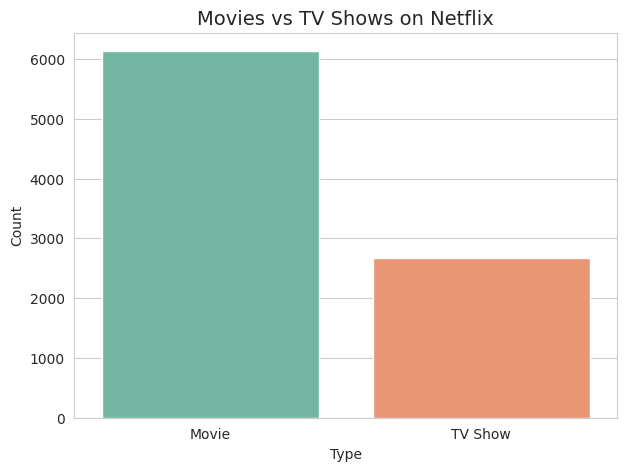

In [32]:
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Movies vs TV Shows on Netflix', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


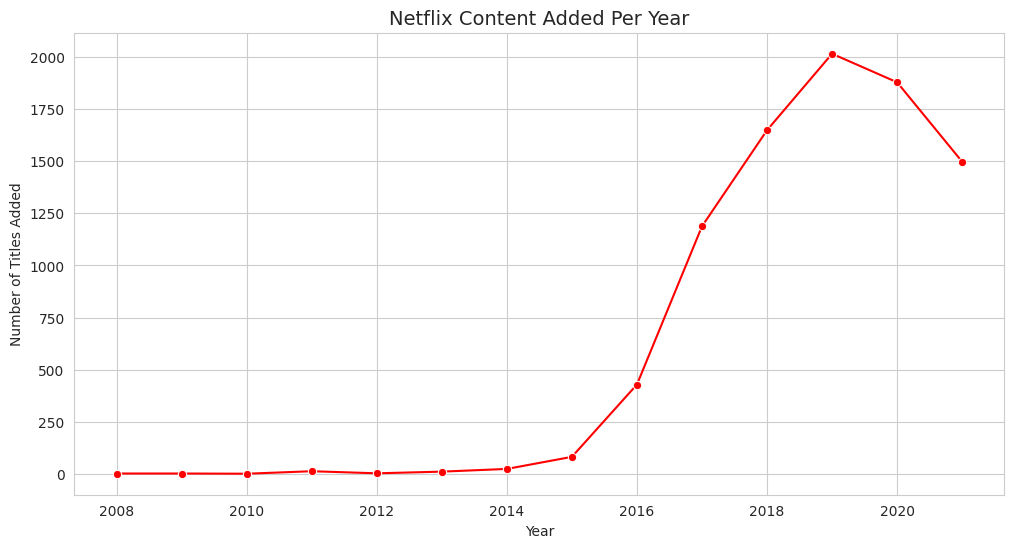

In [33]:
plt.figure(figsize=(12,6))
year_counts = df['year_added'].value_counts().sort_index()
print(year_counts)

sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='red')
plt.title('Netflix Content Added Per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.show()

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


/tmp/ipykernel_58/2469463928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


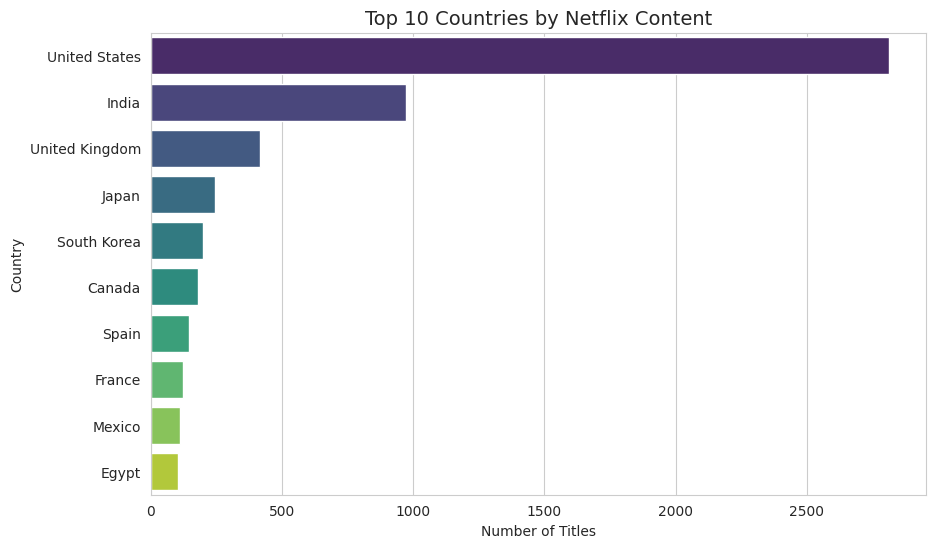

In [34]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Netflix Content', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


/tmp/ipykernel_58/1851170207.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')


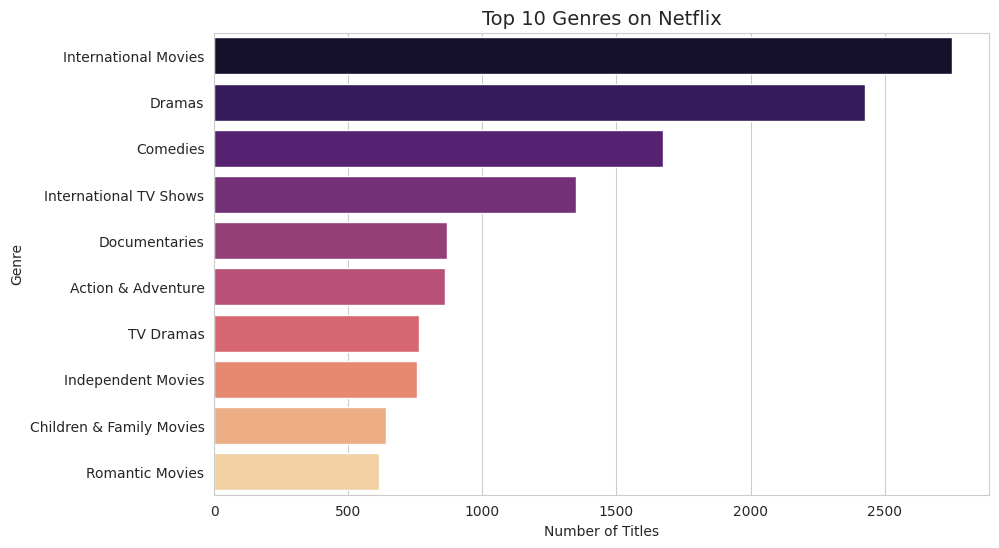

In [35]:
# Sare genres ko split aur explode karna
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)
print(top_genres)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Genres on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
Not Rated       7
TV-Y7-FV        6
NC-17           3
UR              3
Name: count, dtype: int64


/tmp/ipykernel_58/815373548.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='coolwarm')


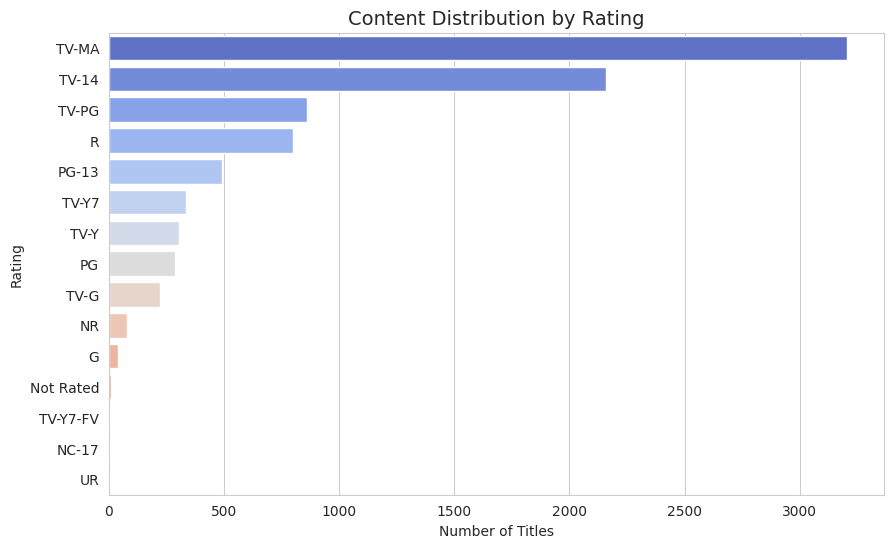

In [38]:
plt.figure(figsize=(10,6))
rating_counts = df['rating'].value_counts()
print(rating_counts)

sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='coolwarm')
plt.title('Content Distribution by Rating', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()

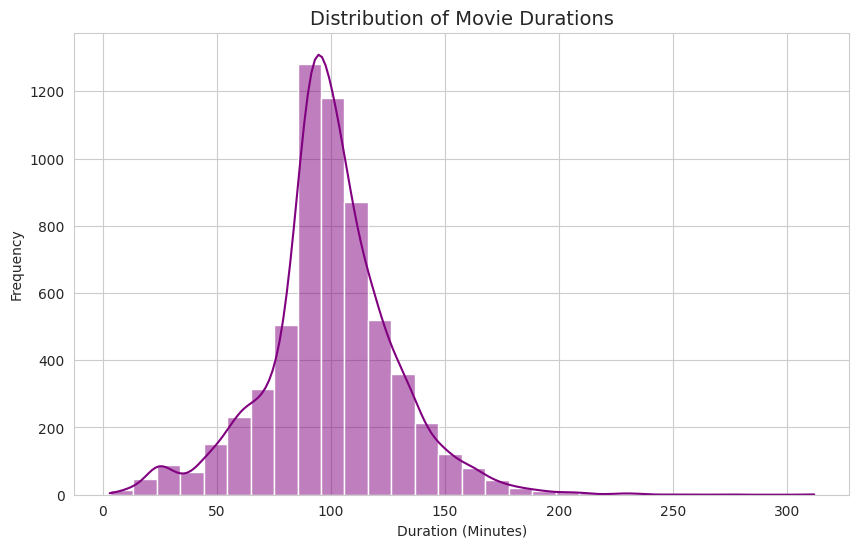

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64


In [39]:
plt.figure(figsize=(10,6))
sns.histplot(df['duration_minutes'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Durations', fontsize=14)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

print(df['duration_minutes'].describe())

/tmp/ipykernel_58/3407256126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['type']=='TV Show'], x='duration_seasons', palette='cool')


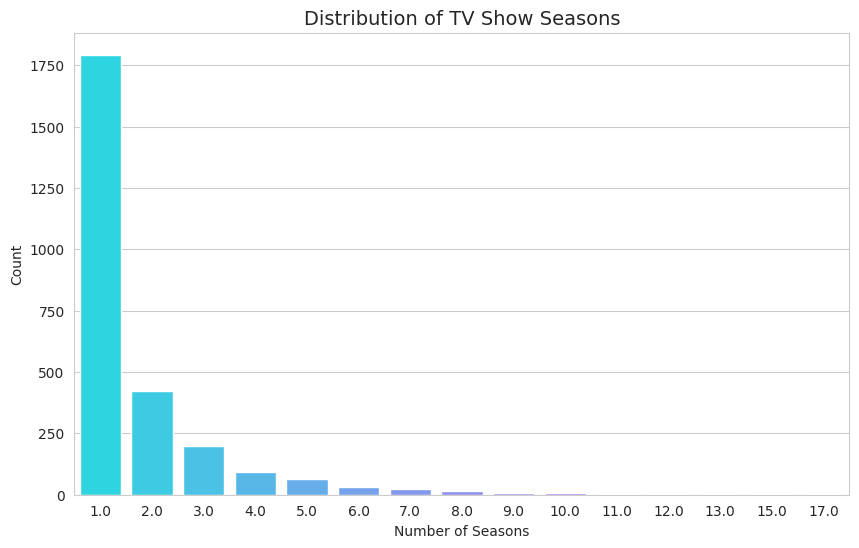

count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_seasons, dtype: float64


In [40]:
plt.figure(figsize=(10,6))
sns.countplot(data=df[df['type']=='TV Show'], x='duration_seasons', palette='cool')
plt.title('Distribution of TV Show Seasons', fontsize=14)
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.show()

print(df['duration_seasons'].describe())

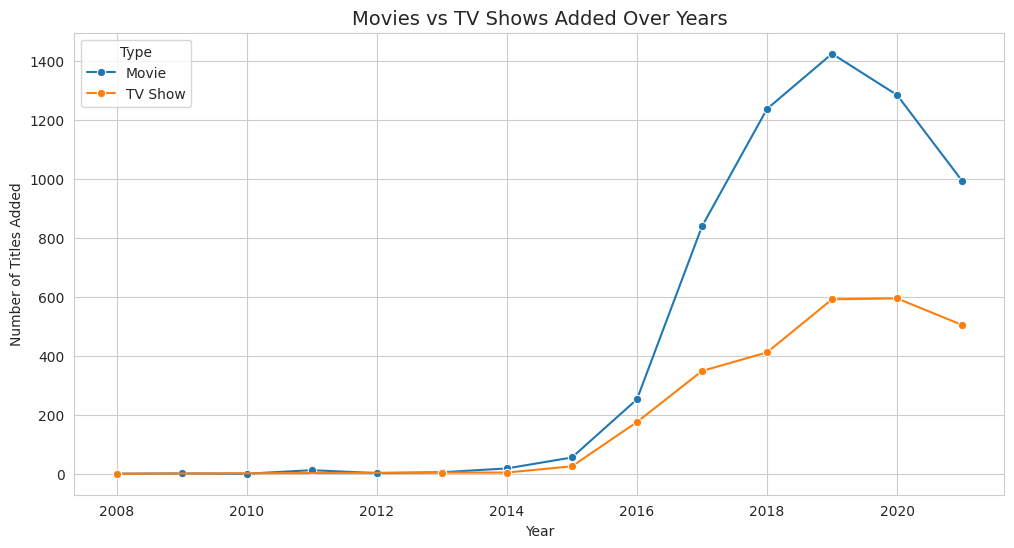

In [41]:
plt.figure(figsize=(12,6))
yearly_type = df.groupby(['year_added', 'type']).size().reset_index(name='count')

sns.lineplot(data=yearly_type, x='year_added', y='count', hue='type', marker='o')
plt.title('Movies vs TV Shows Added Over Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type')
plt.show()

## 📊 Business Insights Summary

### 1. Content Type Strategy
Netflix ka library **movie-heavy** hai (6131 Movies vs 2666 TV Shows, ~70:30 ratio). Yeh suggest karta hai ke historically Netflix ne content volume ke liye movies pe zyada invest kiya.

### 2. Growth Trajectory
2016-2019 ke beech Netflix ne **aggressive content expansion** ki (90 titles/year se 2000+ titles/year tak), jo streaming competition ki entry se time-aligned hai.

### 3. Global Content Strategy
**India dusra sabse bara content market hai** (972 titles) US ke baad. UK, Japan, South Korea bhi top 5 mein hain.

### 4. Genre Focus
**"International Movies" sabse top genre hai** (2752 titles), Dramas aur Comedies ke baad.

### 5. Target Audience
**61% content mature/teen audience (TV-MA + TV-14) ke liye hai**, kids content sirf ~10% hai.

### 6. Content Format Patterns
- Average movie length: ~99.5 minutes
- Majority TV Shows sirf 1 season tak chalti hain (median = 1)

### 7. Movies vs TV Shows Trend
TV Shows zyada resilient/stable rahi hain 2020 ke baad ke decline mein, Movies ke comparison mein.

## 🎯 Key Recommendations
1. TV Shows mein investment badhana chahiye
2. Early cancellation policy review karni chahiye  
3. India/South Korea jese growing markets mein continued investment
4. Kids content segment expand karne ka opportunity hai